# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os

# Пытаемся загрузить с локального пути, если нет - с серверного
try:
    sessions_history = pd.read_csv('C:/Users/mobil/Downloads/sessions_project_history.csv')
    print("Локальная загрузка")
except FileNotFoundError:
    sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
    print("Серверная загрузка")

Локальная загрузка


In [3]:
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
user_sessions_count = sessions_history.groupby('user_id')['session_id'].nunique().reset_index()
user_sessions_count.columns = ['user_id', 'session_count']
user_sessions_count_sorted = user_sessions_count.sort_values('session_count', ascending=False)
print("Топ-10 пользователей по количеству сессий:")
display(user_sessions_count_sorted.head(10))

Топ-10 пользователей по количеству сессий:


,user_id,session_count
8948,10E0DEFC1ABDBBE0,10
55627,6A73CB5566BB494D,10
72346,8A60431A825D035B,9
109383,D11541BAC141FB94,9
47956,5BCFE7C4DCC148E9,9
22611,2AF89E9BC4D631A3,9
29354,37E4825C6A22A519,9
53434,66374F4203EFEDA7,9
16936,1FE6E098C8A7E9A3,9
84534,A1E1B4CCA664587C,9


In [5]:
max_sessions_user = user_sessions_count_sorted.iloc[0]['user_id']
max_sessions = user_sessions_count_sorted.iloc[0]['session_count']

print(f"\nПользователь с наибольшим количеством сессий: {max_sessions_user}")
print(f"Количество сессий: {max_sessions}")


Пользователь с наибольшим количеством сессий: 10E0DEFC1ABDBBE0
Количество сессий: 10


In [6]:
user_data = sessions_history[sessions_history['user_id'] == max_sessions_user]
print(f"\nВсе данные для пользователя {max_sessions_user}:")
display(user_data.sort_values('session_date')) 


Все данные для пользователя 10E0DEFC1ABDBBE0:


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

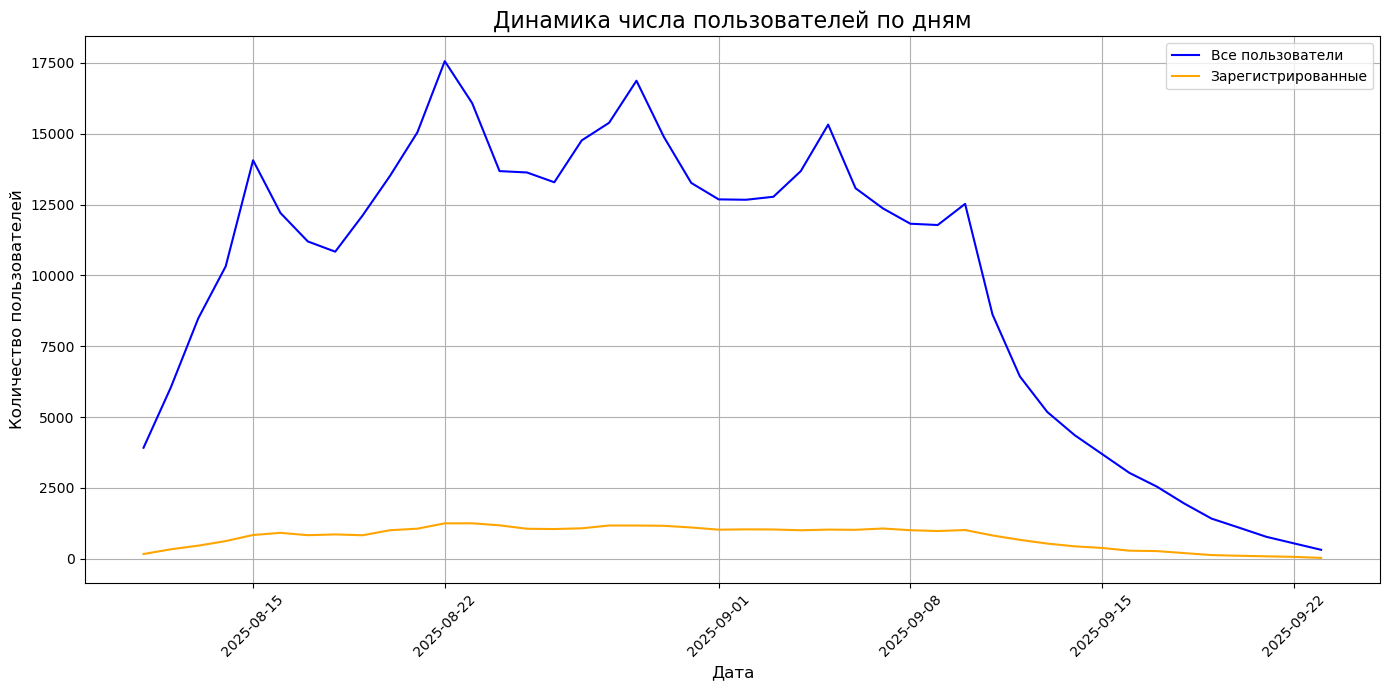

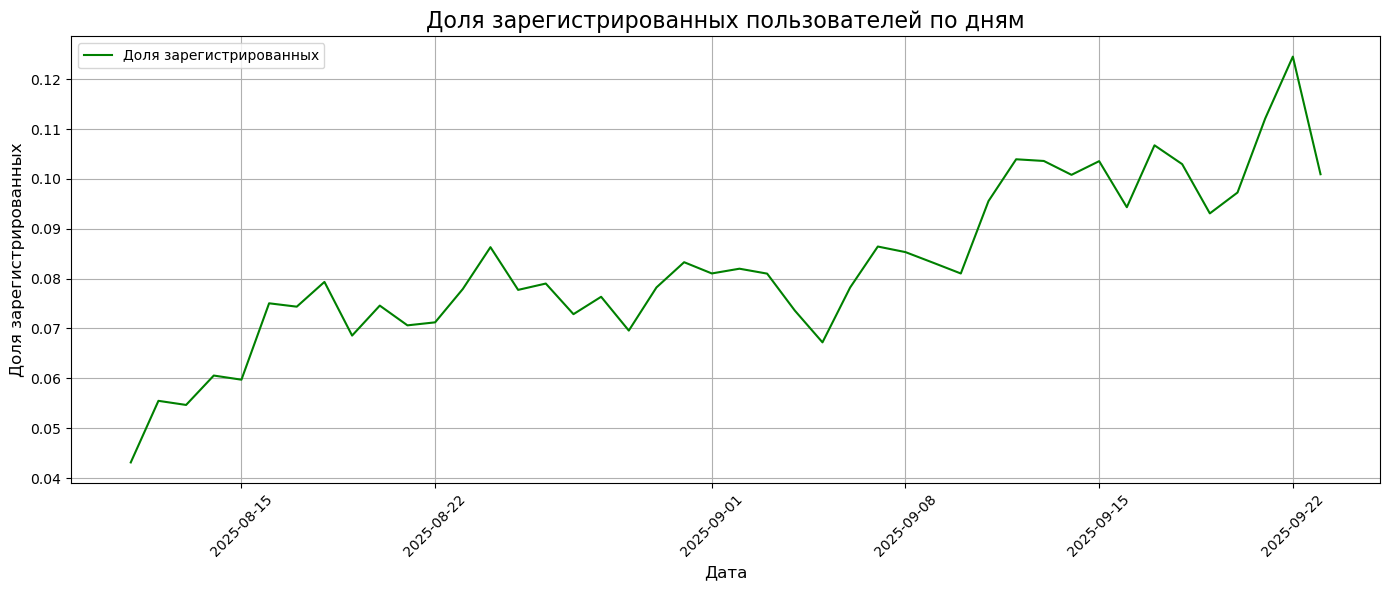

In [7]:
sessions_history = pd.read_csv('C:/Users/mobil/Downloads/sessions_project_history.csv')

sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

daily_stats = sessions_history.groupby('session_date').agg({
    'user_id': 'nunique',
    'registration_flag': 'sum'
}).reset_index()

daily_stats.columns = ['session_date', 'total_users', 'registered_users']

plt.figure(figsize=(14, 7))
plt.plot(daily_stats['session_date'], daily_stats['total_users'], label='Все пользователи', color='blue')
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], label='Зарегистрированные', color='orange')
plt.title('Динамика числа пользователей по дням', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

daily_stats['share'] = daily_stats['registered_users'] / daily_stats['total_users']

plt.figure(figsize=(14, 6))
plt.plot(daily_stats['session_date'], daily_stats['share'], label='Доля зарегистрированных', color='green')
plt.title('Доля зарегистрированных пользователей по дням', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля зарегистрированных', fontsize=12)
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

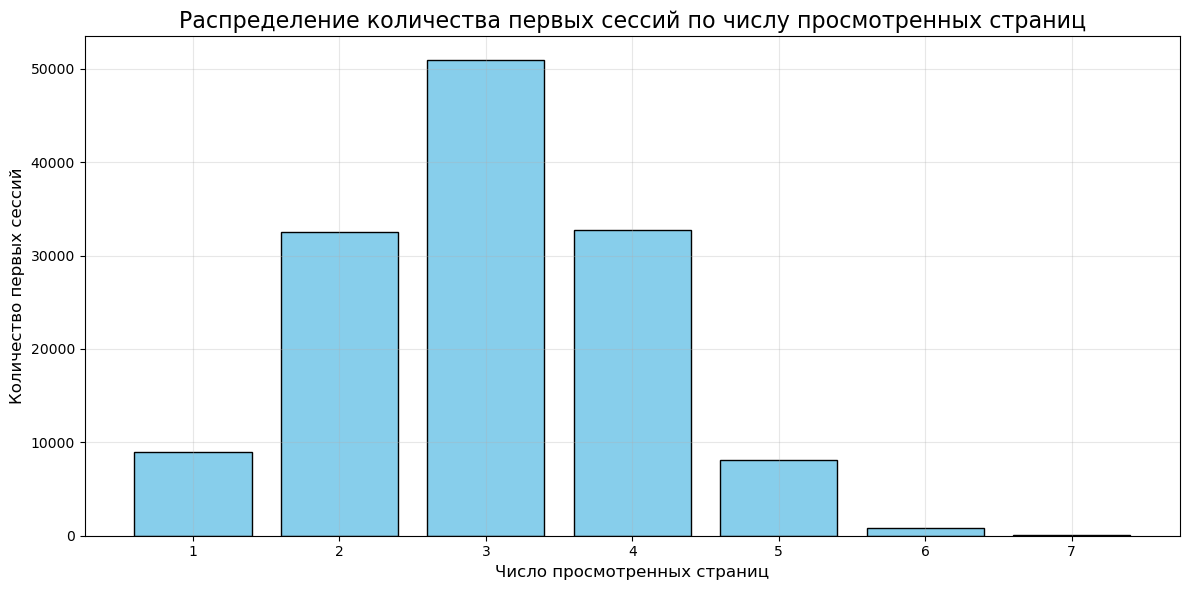

Статистика по первым сессиям:
Всего первых сессий: 134039
Среднее число просмотренных страниц в первой сессии: 3.01
Медианное число просмотренных страниц: 3.0
Максимальное число просмотренных страниц: 7


In [8]:
# Находим первые сессии пользователей (session_number == 1)
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Считаем количество первых сессий для каждого значения просмотренных страниц
page_counts = first_sessions['page_counter'].value_counts().sort_index()

# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))
plt.bar(page_counts.index, page_counts.values, color='skyblue', edgecolor='black')
plt.title('Распределение количества первых сессий по числу просмотренных страниц', fontsize=16)
plt.xlabel('Число просмотренных страниц', fontsize=12)
plt.ylabel('Количество первых сессий', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Выводим статистику
print("Статистика по первым сессиям:")
print(f"Всего первых сессий: {len(first_sessions)}")
print(f"Среднее число просмотренных страниц в первой сессии: {first_sessions['page_counter'].mean():.2f}")
print(f"Медианное число просмотренных страниц: {first_sessions['page_counter'].median()}")
print(f"Максимальное число просмотренных страниц: {first_sessions['page_counter'].max()}")

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

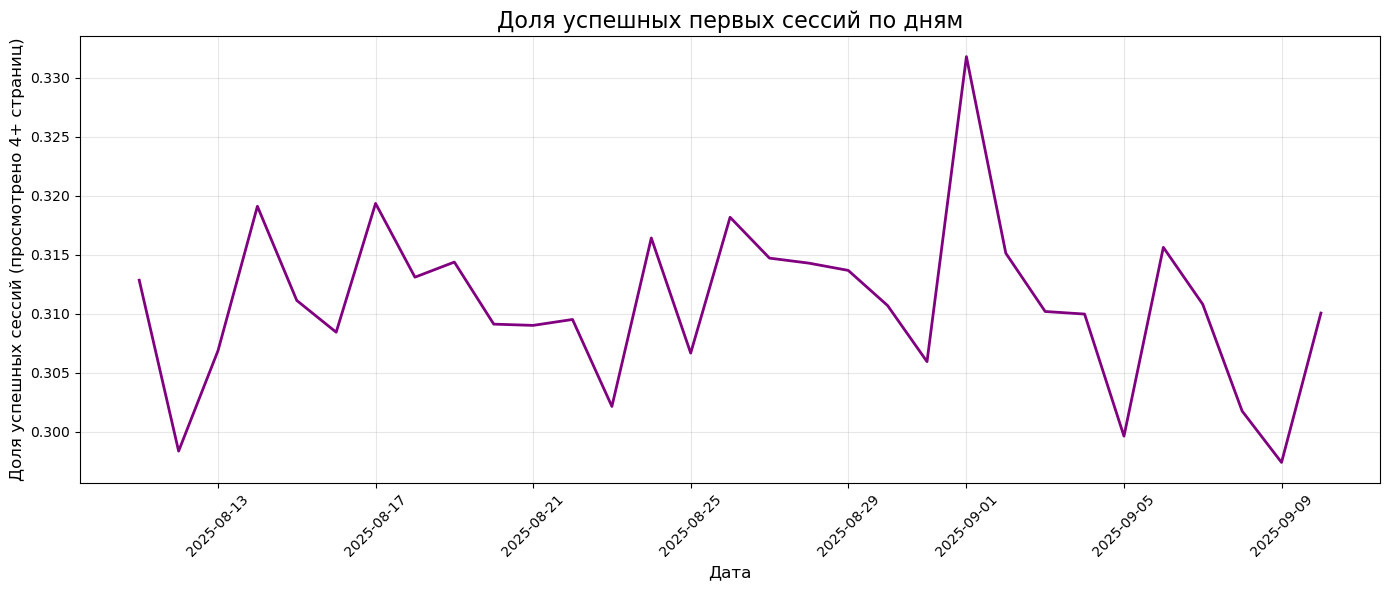

In [9]:
# Создаем столбец good_session
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# Оставляем только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Группируем по дням и считаем долю успешных сессий
daily_good_share = first_sessions.groupby('session_date').agg({
    'good_session': 'mean'  # среднее = доля успешных сессий
}).reset_index()

daily_good_share.columns = ['session_date', 'good_share']

# Строим график
plt.figure(figsize=(14, 6))
plt.plot(daily_good_share['session_date'], daily_good_share['good_share'], color='purple', linewidth=2)
plt.title('Доля успешных первых сессий по дням', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля успешных сессий (просмотрено 4+ страниц)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [10]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода
power = 0.8  # Мощность теста (1 - beta)
p = 0.3  # Базовый уровень доли
mde = p * 0.03  # Минимальный детектируемый эффект (3%)

effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1  # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [11]:
from math import ceil

# Среднее количество уникальных пользователей в день
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Размер выборки для одной группы
sample_size_per_group = int(sample_size)

# Общий размер выборки (две группы)
total_sample_size = sample_size_per_group * 2 

# Длительность теста в днях
test_duration = ceil(total_sample_size / avg_daily_users)

print(f"Среднее количество уникальных пользователей в день: {avg_daily_users:.0f}")
print(f"Общий необходимый размер выборки: {total_sample_size} пользователей")
print(f"Рассчитанная длительность A/B-теста: {test_duration} дней")

Среднее количество уникальных пользователей в день: 9907
Общий необходимый размер выборки: 82080 пользователей
Рассчитанная длительность A/B-теста: 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [12]:
try:
    sessions_test_part = pd.read_csv('C:/Users/mobil/Downloads/sessions_project_test_part.csv')
    print("Локальная загрузка")
except FileNotFoundError:
    sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')
    print("Серверная загрузка")

Локальная загрузка


Количество уникальных пользователей в группе A: 1477
Количество уникальных пользователей в группе B: 1466
Процентная разница между группами: 0.74%


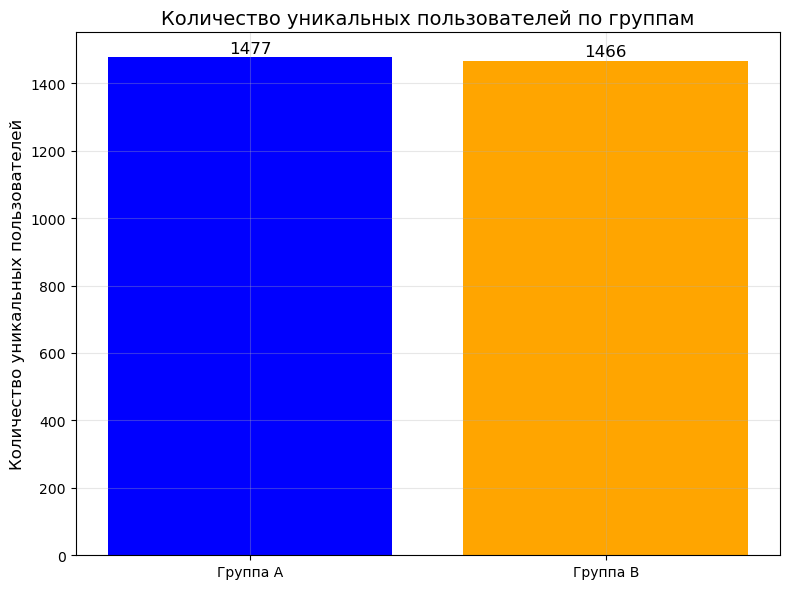

In [13]:
# Рассчитываем количество уникальных пользователей в каждой группе
users_group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()
users_group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()

print(f"Количество уникальных пользователей в группе A: {users_group_a}")
print(f"Количество уникальных пользователей в группе B: {users_group_b}")

# Процентная разница
percent_diff = 100 * abs(users_group_a - users_group_b) / users_group_a
print(f"Процентная разница между группами: {percent_diff:.2f}%")

# Визуализация
plt.figure(figsize=(8, 6))
groups = ['Группа A', 'Группа B']
users = [users_group_a, users_group_b]
plt.bar(groups, users, color=['blue', 'orange'])
plt.title('Количество уникальных пользователей по группам', fontsize=14)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.grid(True, alpha=0.3)
for i, v in enumerate(users):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [14]:
# Находим пользователей в группе A
users_a = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])

# Находим пользователей в группе B
users_b = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

# Находим пересечение - пользователи, которые есть в обеих группах
overlap = users_a.intersection(users_b)

# Выводим результат
print(f"Количество пользователей в группе A: {len(users_a)}")
print(f"Количество пользователей в группе B: {len(users_b)}")
print(f"Количество пользователей, попавших в обе группы: {len(overlap)}")

if len(overlap) == 0:
    print("Группы независимы! Ни один пользователь не попал в обе группы одновременно.")
else:
    print(f"Найдено {len(overlap)} пользователей, которые есть в обеих группах:")
    print(overlap)

Количество пользователей в группе A: 1477
Количество пользователей в группе B: 1466
Количество пользователей, попавших в обе группы: 0
Группы независимы! Ни один пользователь не попал в обе группы одновременно.


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


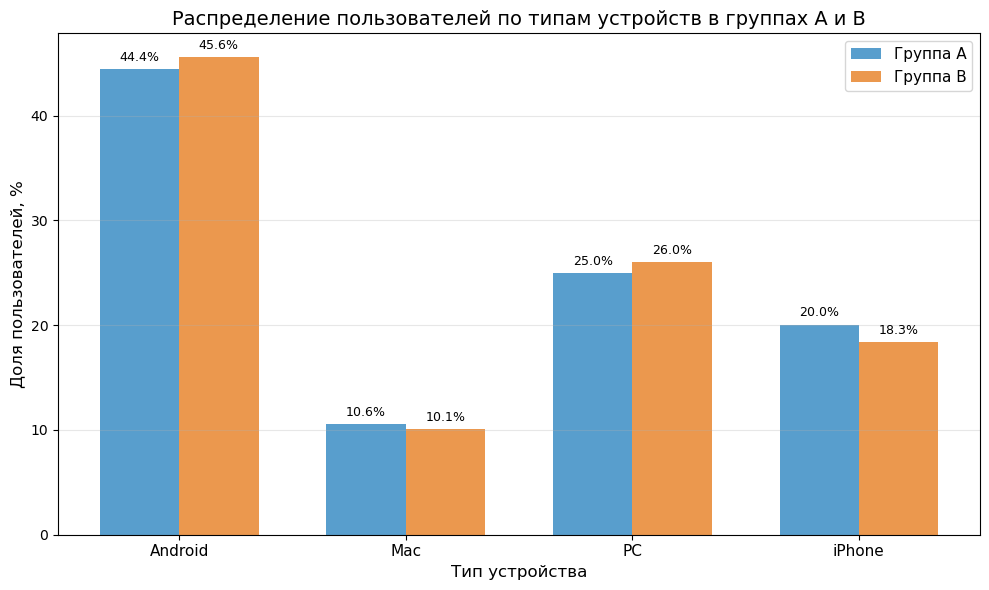

Распределение устройств по группам (по уникальным пользователям):

Группа A:
device
Android    44.41
Mac        10.56
PC         24.98
iPhone     20.04
Name: user_id, dtype: float64

Группа B:
device
Android    45.57
Mac        10.10
PC         25.99
iPhone     18.35
Name: user_id, dtype: float64

Разница в процентах:
device
Android    1.15
Mac        0.47
PC         1.01
iPhone     1.69
Name: user_id, dtype: float64

Максимальная разница: 1.69% для iPhone


In [15]:
# Данные по группе A - считаем уникальных пользователей по устройствам
group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']
device_a = group_a.groupby('device')['user_id'].nunique()
device_a = (device_a / device_a.sum()) * 100

# Данные по группе B - считаем уникальных пользователей по устройствам
group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']
device_b = group_b.groupby('device')['user_id'].nunique()
device_b = (device_b / device_b.sum()) * 100

# Объединяем данные
devices = sorted(set(device_a.index) | set(device_b.index))
a_values = [device_a.get(d, 0) for d in devices]
b_values = [device_b.get(d, 0) for d in devices]

# Строим grouped bar chart
plt.figure(figsize=(10, 6))
x = np.arange(len(devices))
width = 0.35

plt.bar(x - width/2, a_values, width, label='Группа A', color='#2E86C1', alpha=0.8)
plt.bar(x + width/2, b_values, width, label='Группа B', color='#E67E22', alpha=0.8)

# Добавляем значения на столбцы
for i, (a, b) in enumerate(zip(a_values, b_values)):
    plt.text(i - width/2, a + 0.5, f'{a:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, b + 0.5, f'{b:.1f}%', ha='center', va='bottom', fontsize=9)

plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('Доля пользователей, %', fontsize=12)
plt.title('Распределение пользователей по типам устройств в группах A и B', fontsize=14)
plt.xticks(x, devices, fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Вывод статистики для сравнения
print("Распределение устройств по группам (по уникальным пользователям):")
print("\nГруппа A:")
print(device_a.round(2))
print("\nГруппа B:")
print(device_b.round(2))
print("\nРазница в процентах:")
diff = (device_a - device_b).abs()
print(diff.round(2))

# Максимальная разница
max_diff = diff.max()
max_device = diff.idxmax()
print(f"\nМаксимальная разница: {max_diff:.2f}% для {max_device}")

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

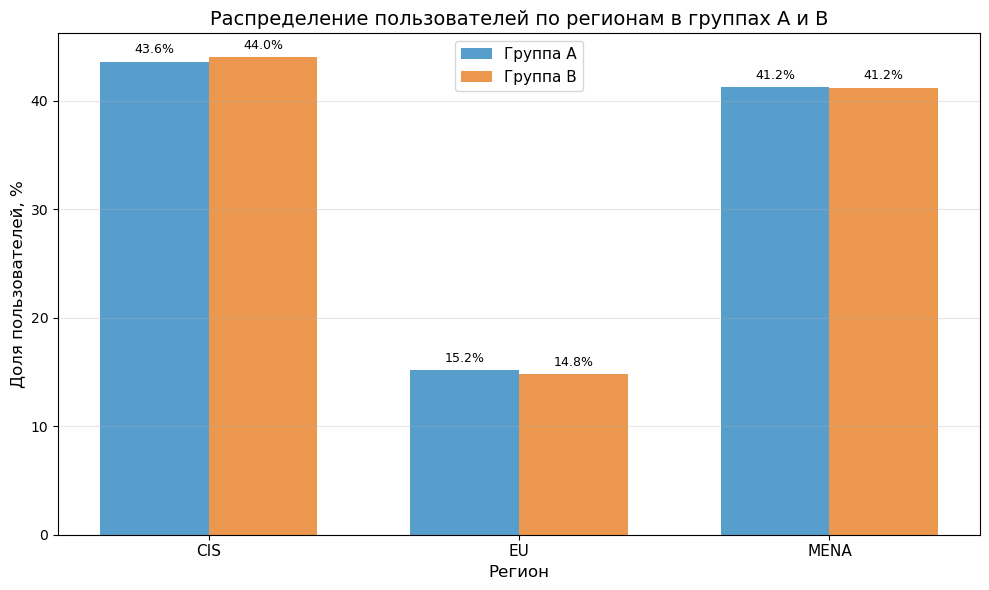

Распределение регионов по группам (по уникальным пользователям):

Группа A:
region
CIS     43.60
EU      15.17
MENA    41.23
Name: user_id, dtype: float64

Группа B:
region
CIS     44.0
EU      14.8
MENA    41.2
Name: user_id, dtype: float64

Разница в процентах:
region
CIS     0.40
EU      0.36
MENA    0.03
Name: user_id, dtype: float64

Максимальная разница: 0.40% для CIS

Количество уникальных пользователей по регионам:

Группа A:
region
CIS     644
EU      224
MENA    609
Name: user_id, dtype: int64

Группа B:
region
CIS     645
EU      217
MENA    604
Name: user_id, dtype: int64


In [16]:
# Данные по группе A - считаем уникальных пользователей по регионам
group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']
region_a = group_a.groupby('region')['user_id'].nunique()
region_a = (region_a / region_a.sum()) * 100

# Данные по группе B - считаем уникальных пользователей по регионам
group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']
region_b = group_b.groupby('region')['user_id'].nunique()
region_b = (region_b / region_b.sum()) * 100

# Объединяем данные
regions = sorted(set(region_a.index) | set(region_b.index))
a_values = [region_a.get(r, 0) for r in regions]
b_values = [region_b.get(r, 0) for r in regions]

# Строим grouped bar chart
plt.figure(figsize=(10, 6))
x = np.arange(len(regions))
width = 0.35

plt.bar(x - width/2, a_values, width, label='Группа A', color='#2E86C1', alpha=0.8)
plt.bar(x + width/2, b_values, width, label='Группа B', color='#E67E22', alpha=0.8)

# Добавляем значения на столбцы
for i, (a, b) in enumerate(zip(a_values, b_values)):
    plt.text(i - width/2, a + 0.5, f'{a:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, b + 0.5, f'{b:.1f}%', ha='center', va='bottom', fontsize=9)

plt.xlabel('Регион', fontsize=12)
plt.ylabel('Доля пользователей, %', fontsize=12)
plt.title('Распределение пользователей по регионам в группах A и B', fontsize=14)
plt.xticks(x, regions, fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Вывод статистики для сравнения
print("Распределение регионов по группам (по уникальным пользователям):")
print("\nГруппа A:")
print(region_a.round(2))
print("\nГруппа B:")
print(region_b.round(2))
print("\nРазница в процентах:")
diff = (region_a - region_b).abs()
print(diff.round(2))

# Максимальная разница
max_diff = diff.max()
max_region = diff.idxmax()
print(f"\nМаксимальная разница: {max_diff:.2f}% для {max_region}")

# Дополнительно: количество уникальных пользователей по регионам
print("\nКоличество уникальных пользователей по регионам:")
print("\nГруппа A:")
print(group_a.groupby('region')['user_id'].nunique())
print("\nГруппа B:")
print(group_b.groupby('region')['user_id'].nunique())


#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

---

- Различие в количестве пользователей в группах
  Различие обнаружено, но оно незначительное:

Группа A: 1477 пользователей

Группа B: 1466 пользователей

Процентная разница: 0.74%

Такое небольшое расхождение (менее 1%) является допустимым и может быть связано со случайной вариативностью. 

- Независимость выборок
Выборки полностью независимы:

Пересечение пользователей между группами: 0

Ни один пользователь не попал одновременно в группы A и B

Это отличный результат, означающий, что распределение выполнено корректно и пользователи распределены по взаимоисключающим группам.

- Равномерность распределения по устройствам

Распределение устройств близко к равномерному

Максимальная разница составляет 1.69% для iPhone, что является приемлемым значением и свидетельствует о хорошем балансе групп по типу устройств.

- Равномерность распределения по регионам

Распределение регионов близко к равномерному.

Максимальная разница составляет 0.40% для региона CIS, что является отличным показателем и свидетельствует о хорошем балансе групп по регионам.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [17]:
try:
    sessions_test = pd.read_csv('C:/Users/mobil/Downloads/sessions_project_test.csv')
    print("Локальная загрузка")
except FileNotFoundError:
    sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')
    print("Серверная загрузка")

Локальная загрузка


In [18]:
# Создаем столбец good_session
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.


##### Целевая метрика
**Доля успешных сессий** (просмотрено 4+ страниц)

##### Нулевая гипотеза (H₀)
Новый алгоритм **не влияет** на долю успешных сессий.

**H₀: p_B = p_A**

##### Альтернативная гипотеза (H₁)
Новый алгоритм **увеличивает** долю успешных сессий.

**H₁: p_B > p_A**

Где:
- p_A — контрольная группа (старый алгоритм)
- p_B — тестовая группа (новый алгоритм)

---

##### Прокси-метрики (быстрая оценка)

1. Среднее число просмотренных страниц
2. Длительность сессии
3. Возвращаемость на следующий день (Retention Day 1)

---

##### Барьерные метрики (что может пойти не так)

1. Доля коротких сессий (1-2 страницы) — растет → контент хуже
2. Время загрузки — увеличивается → технические проблемы
3. Отток пользователей — растет → пользователи уходят


#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [19]:
# Фильтруем только первые сессии
first_sessions = sessions_test[sessions_test['session_number'] == 1]

# Доля успешных сессий в группе A
good_share_a = first_sessions[first_sessions['test_group'] == 'A']['good_session'].mean()

# Доля успешных сессий в группе B
good_share_b = first_sessions[first_sessions['test_group'] == 'B']['good_session'].mean()

# Разница
difference = good_share_b - good_share_a

print(f"Доля успешных первых сессий в группе A: {good_share_a:.2%}")
print(f"Доля успешных первых сессий в группе B: {good_share_b:.2%}")
print(f"Разница (B - A): {difference:.2%}")

Доля успешных первых сессий в группе A: 31.57%
Доля успешных первых сессий в группе B: 31.47%
Разница (B - A): -0.11%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [20]:
from scipy.stats import chi2_contingency

# Фильтруем первые сессии
first_sessions = sessions_test[sessions_test['session_number'] == 1]

# Создаем таблицу сопряженности
contingency_table = pd.crosstab(first_sessions['test_group'], first_sessions['good_session'])

print("Таблица сопряженности:")
print(contingency_table)

# Хи-квадрат тест
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nХи-квадрат: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")

# Вывод
alpha = 0.05
if p_value < alpha:
    print("\n✅ Результат статистически значим. Отвергаем H₀.")
    print("Новый алгоритм влияет на долю успешных сессий.")
else:
    print("\n❌ Результат не статистически значим. Не отвергаем H₀.")
    print("Нет оснований считать, что новый алгоритм меняет долю успешных сессий.")

Таблица сопряженности:
good_session      0     1
test_group               
A             10375  4787
B             10565  4851

Хи-квадрат: 0.0344
p-value: 0.8529

❌ Результат не статистически значим. Не отвергаем H₀.
Нет оснований считать, что новый алгоритм меняет долю успешных сессий.


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

In [21]:
# Реальная длительность теста
min_date = sessions_test['session_date'].min()
max_date = sessions_test['session_date'].max()
test_duration_real = (pd.to_datetime(max_date) - pd.to_datetime(min_date)).days + 1

print(f"Дата начала теста: {min_date}")
print(f"Дата окончания теста: {max_date}")
print(f"Реальная длительность теста: {test_duration_real} дней")

# Количество уникальных пользователей в каждой группе
users_a = sessions_test[sessions_test['test_group'] == 'A']['user_id'].nunique()
users_b = sessions_test[sessions_test['test_group'] == 'B']['user_id'].nunique()

print(f"\nКоличество уникальных пользователей в группе A: {users_a:,}")
print(f"Количество уникальных пользователей в группе B: {users_b:,}")
print(f"Всего пользователей: {users_a + users_b:,}")

# Количество сессий в каждой группе
sessions_a = sessions_test[sessions_test['test_group'] == 'A'].shape[0]
sessions_b = sessions_test[sessions_test['test_group'] == 'B'].shape[0]

print(f"\nКоличество сессий в группе A: {sessions_a:,}")
print(f"Количество сессий в группе B: {sessions_b:,}")

# Среднее количество сессий на пользователя
avg_sessions_a = sessions_a / users_a
avg_sessions_b = sessions_b / users_b

print(f"\nСреднее количество сессий на пользователя в группе A: {avg_sessions_a:.2f}")
print(f"Среднее количество сессий на пользователя в группе B: {avg_sessions_b:.2f}")

Дата начала теста: 2025-10-14
Дата окончания теста: 2025-11-02
Реальная длительность теста: 20 дней

Количество уникальных пользователей в группе A: 15,163
Количество уникальных пользователей в группе B: 15,416
Всего пользователей: 30,579

Количество сессий в группе A: 49,551
Количество сессий в группе B: 50,454

Среднее количество сессий на пользователя в группе A: 3.27
Среднее количество сессий на пользователя в группе B: 3.27


#### Характеристики эксперимента

- **Целевая метрика:** доля успешных первых сессий (4+ страниц)
- **Группа A (контроль):** 15,163 пользователей, старый алгоритм
- **Группа B (тест):** 15,416 пользователей, новый алгоритм
- **Длительность:** 20 дней (с 2025-10-14 по 2025-11-02)
- **Уровень значимости:** α = 0.05

#### Результаты эксперимента

- Группа A: 31.57%
- Группа B: 31.47%
- Разница: -0.11 процентных пункта
- **p-value = 0.8529**

Внедрение нового алгоритма не оказало статистически значимого влияния на долю успешных первых сессий. В тестовой группе показатель составил 31.47%, что на 0.11 процентных пункта ниже, чем в контрольной группе (31.57%). Небольшое снижение метрики, скорее всего, связано со случайной вариативностью, а не с эффектом нового алгоритма.

#### p-value

Полученное значение **p-value = 0.8529** значительно превышает установленный уровень значимости α = 0.05. Это означает, что вероятность наблюдать такие или более экстремальные различия при условии, что новый алгоритм не работает, составляет более 85%. Следовательно, статистически значимых оснований считать, что новый алгоритм улучшает ключевую метрику, нет.

#### Заключение

❌ **Новый алгоритм не показал статистически значимого эффекта**

p-value = 0.853 > 0.05, значит различия случайны.

#### Рекомендация

🔴 **Не внедрять** новый алгоритм в текущей версии.

#### Дальнейшие шаги

1. Проанализировать алгоритм на других сегментах пользователей
2. Проверить другие метрики (удержание, время сессии)
3. Доработать алгоритм и провести повторный тест